# Diciplina de Machine Learning - Pós-Graduação PUC-RIO
### MVP apresentado como atividade final da Sprint de Machine Learning

Criação de modelo de Machine Learning destinado à classificação de risco de hipertensão.

Objetivo: Aplicação em dispositivos de monitoramento físico e aplicativos de treinamento físico.

Conjunto de dados empregado para análise:
Hypertension Risk Prediction Dataset

Fonte: https://www.kaggle.com/datasets/miadul/hypertension-risk-prediction-dataset

<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Machine_Learnin-PUC-RIO/blob/main/notebooks/hypertension_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação das bibliotecas necessárias para o projeto

In [25]:
# importação de bibliotecas básicas
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# importação de métodos de tratamento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA

# importação de modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

# importação de ensembles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier


# configuração para não exibir os warnings
warnings.filterwarnings("ignore")

# definição da semente aleatória visando a reprodutibilidade
SEED = 42

## Coleta, análise e tratamento dos dados

In [26]:
data_path = "../dados/hypertension_dataset.csv"
url = "https://raw.githubusercontent.com/rogerioferreira/MVP-Machine_Learning-PUC-RIO/refs/heads/main/dados/hypertension_dataset.csv"

if os.path.exists(data_path):
    # caraga do dataset localmente, caso presente
    df = pd.read_csv(data_path)
else:
    # caraga do dataset diretamente pelo Git Hub
    df = pd.read_csv(url)

### Verificação da ocorrência de dados nulos no dataframe

Foi oservada a ausência de registro do uso de medicação continuada para uma parcela significativa das ocorrências (40% dos casos), contudo, considera-se que a ausência de registro sobre o uso de medicação contínua em prontuários médicos é uma informação válida. Desta forma, tais registros foram marcados como não fazendo usos de nenhuma medicação de uso contínuo.

In [27]:
# verificação da presença de valores nulos
df.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [28]:
# calculo do percentual de dados nulos
percentual = (df["Medication"].isnull().sum() / len(df)) * 100
print(f"O percentual de dados nulos: {percentual:.2f}%")

O percentual de dados nulos: 40.25%


In [29]:
# atribuição de informação de não uso de medicação nos registros nulos
df["Medication"].fillna("No Medication", inplace=True)

### Verificação de dados duplicados no dataframe

Não foram observadas ocorrências de duplicidades nos dados.

In [30]:
# verificação da presença de dados duplicados
print(df.duplicated().any())

False


In [31]:
# verificação da quantidade de entradas duplicadas no dataframe
print(f"Quantidade de registro duplicados: {df.duplicated().sum()}")

# remoção de entradas duplicadas
# reinicialização do index para evitar geração da valores NaN
# df = df.drop_duplicates(keep="first").reset_index(drop=True)

Quantidade de registro duplicados: 0


### Verificação de outliers

Foram analisadas as features "Age", "Salt_Intake", "Stress_Score", "Sleep_Duration", "BMI". 

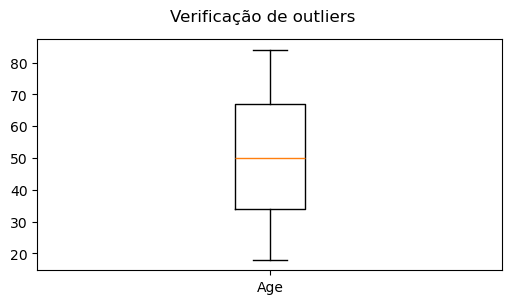

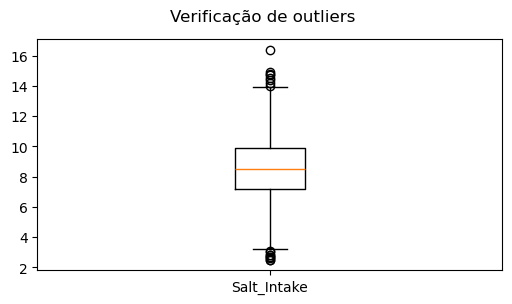

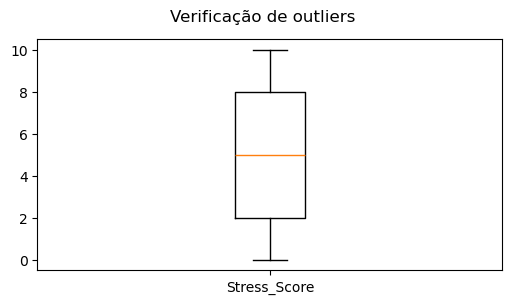

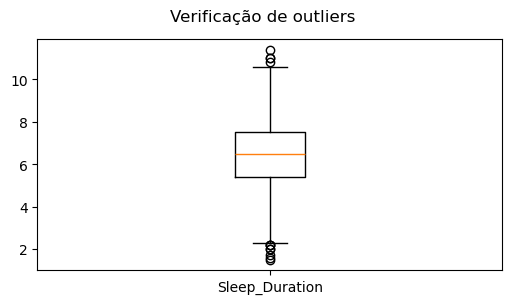

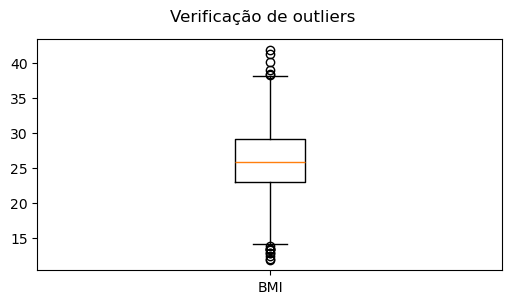

In [32]:
# identificação de outliers nas variáveis não categóricas ou binárias

features = ["Age", "Salt_Intake", "Stress_Score", "Sleep_Duration", "BMI"]


for feature in features:
    fig, ax = plt.subplots(figsize=(6, 3))

    fig.suptitle("Verificação de outliers")
    ax.set_xticklabels([feature])

    plt.boxplot(df[feature])
    plt.show()

In [33]:
df[features].describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [34]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,No Medication,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,No Medication,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,No Medication,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


### Tratamento de variáveis categóricas e variáveis numéricas

Foi empregado o método OneHotEncoder para as variáveis Gênero (gender) e Histórico de Tabagismo (smoking_history) em virtude da característica categórica das mesmas.

Foi empregado método de Normalização para as variáveis ... 

In [35]:
# realização da transformação de variáveis categóricas não binárias
features = ["BP_History", "Medication"]
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")

one_hot_features = one_hot.fit_transform(df[features])
df_one_hot = pd.DataFrame(
    one_hot_features,
    columns=one_hot.get_feature_names_out(features),
)

df.drop(columns=features, inplace=True)  # remoção das features categóricas
df = pd.concat([df_one_hot, df], axis=1)

del df_one_hot

In [36]:
# realização da transformação de variáveis categóricas binárias ou com sentido sequencial
features = []

features.append(("Family_History", ["No", "Yes"]))
features.append(("Exercise_Level", ["Low", "Moderate", "High"]))
features.append(("Smoking_Status", ["Non-Smoker", "Smoker"]))
features.append(("Has_Hypertension", ["No", "Yes"]))

for feature, ordem in features:
    one_hot = OrdinalEncoder(handle_unknown="error", categories=[ordem])

    one_hot_feature = one_hot.fit_transform(df[[feature]])
    df_one_hot = pd.DataFrame(
        one_hot_feature,
        columns=[feature],
    )

    df.drop(columns=feature, inplace=True)  # remoção das features categóricas
    df = pd.concat([df_one_hot, df], axis=1)

    del df_one_hot

In [37]:
df.head()

,Has_Hypertension,Smoking_Status,Exercise_Level,Family_History,BP_History_Normal,BP_History_Prehypertension,Medication_Beta Blocker,Medication_Diuretic,Medication_No Medication,Medication_Other,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,69,8.0,9,6.4,25.8
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,32,11.7,10,5.4,23.4
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,78,9.5,3,7.1,18.7
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38,10.0,10,4.2,22.1
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,41,9.8,1,5.8,16.2


In [38]:
# conversão das features com valores inteiros para ponto flutuante
df[["Age", "Stress_Score"]] = df[["Age", "Stress_Score"]].astype("float64")

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Has_Hypertension            1985 non-null   float64
 1   Smoking_Status              1985 non-null   float64
 2   Exercise_Level              1985 non-null   float64
 3   Family_History              1985 non-null   float64
 4   BP_History_Normal           1985 non-null   float64
 5   BP_History_Prehypertension  1985 non-null   float64
 6   Medication_Beta Blocker     1985 non-null   float64
 7   Medication_Diuretic         1985 non-null   float64
 8   Medication_No Medication    1985 non-null   float64
 9   Medication_Other            1985 non-null   float64
 10  Age                         1985 non-null   float64
 11  Salt_Intake                 1985 non-null   float64
 12  Stress_Score                1985 non-null   float64
 13  Sleep_Duration              1985 

### Preparação dos dados para seleção de modelos

Foi empregado o método PCA como técnica de redução de dimensionalidade, resultando na consolidação de 13 para 8 caracterŕisticas relevantes para o treinaento, presenvando-se 95% da variância.

In [40]:
# Separação em bases de treino e teste (holdout)
X = df.drop(columns="Has_Hypertension")
y = df["Has_Hypertension"]

# aplicação de ténica de redução de dimensionalidade
# pca = PCA(
#     n_components=0.99, random_state=SEED
# )  # n_components=0.95 mantém 95% da variância
# X = pca.fit_transform(X)

X.shape

(1985, 14)

In [41]:
# preparando dados de treinamento normalizados
scaler = Normalizer()
X_norm = scaler.fit_transform(X)

# preparando dados de treinamento padronizados
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

## Seleção prévia dos modelos

In [57]:
# separação dos conjuntos de treinamento e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.20, random_state=SEED
)  # faz a divisão

# criação dos folds para a validação cruzada
num_particoes = 5  # número de folds da validação cruzada (3, 5, 10)
kfold = KFold(
    n_splits=num_particoes, shuffle=True, random_state=SEED
)  # faz o particionamento em K folds

                           Média  Desvio Padrão
Modelo                                         
AdaBoost                1.000000       0.000000
GradBoostingClassifier  0.985614       0.017166
RandomForest            0.941703       0.027957
DecisionTree            0.905226       0.025944
BaggingClassifier       0.891875       0.025857
SVM                     0.888899       0.022719
LogisticRegression      0.881511       0.020543
ExtraTrees              0.864842       0.039324
GaussianNB              0.836986       0.026023
KNeighbors              0.773331       0.030114


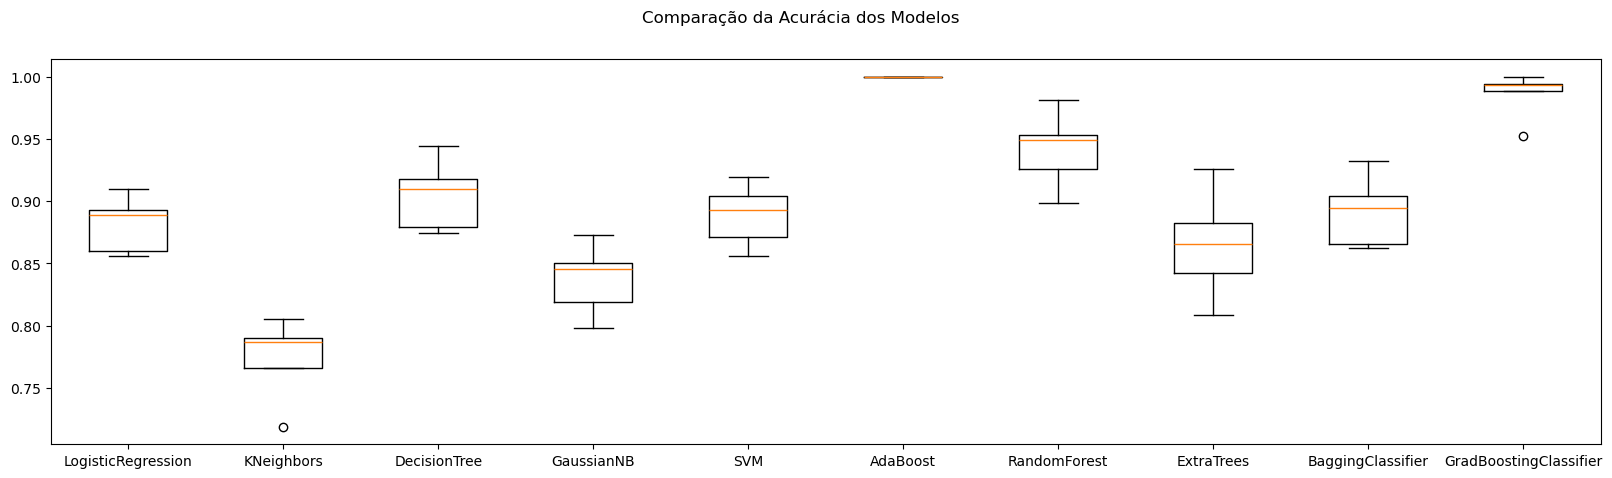

In [61]:
# pré-seleção dos modelos

# criação de listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []
means = []
std = []

# definição dos modelos para teste
models.append(("LogisticRegression", LogisticRegression(random_state=SEED)))
models.append(("KNeighbors", KNeighborsClassifier()))
models.append(("DecisionTree", DecisionTreeClassifier(random_state=SEED)))
models.append(("GaussianNB", GaussianNB()))
models.append(("SVM", SVC(random_state=SEED)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=SEED)))
models.append(("RandomForest", RandomForestClassifier(random_state=SEED)))
models.append(("ExtraTrees", ExtraTreesClassifier(random_state=SEED)))
models.append(("BaggingClassifier", BaggingClassifier(random_state=SEED)))
models.append(("GradBoostingClassifier", GradientBoostingClassifier(random_state=SEED)))


# métricas mais relevantes para seleção dos modelos:
# Acurácia (accuracy): A proporção de predições corretas sobre o total de predições.
# Precisão (precision): Dos casos que o modelo previu como positivos, quantos eram realmente positivos.
# Sensibilidade (recall): Dos casos que eram realmente positivos, quantos o modelo conseguiu identificar.
# Pontuação F1 (f1-score): É a média harmônica entre precisão e recall. É uma métrica útil quando as classes estão desbalanceadas.
# Curva ROC e AUC: Medem a capacidade do modelo de distinguir entre as classes.
for name, model in models:

    print(f"Treinando o modelo: {name}", end='\r')
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="recall")

    results.append(cv_results)
    names.append(name)
    means.append(cv_results.mean())
    std.append(cv_results.std())

    # msg = f"{name:<13} ->   média: {cv_results.mean():>7.4f}   desvio: {cv_results.std():>7.4f}"  # média e desvio padrão dos K resultados da validação cruzada
    # print(msg)

# geraão do dataframe de resultados
df_results = pd.DataFrame(
    {
        "Modelo": names,
        "Média": means,
        "Desvio Padrão": std,
    }
)

# exibição dos resultados
print(df_results.set_index("Modelo").sort_values('Média', ascending=False))

# boxplot de comparação dos modelos
fig = plt.figure(figsize=(20, 5))
fig.suptitle("Comparação da Acurácia dos Modelos")
ax = fig.add_subplot(1, 1, 1)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

## Otimização dos modelos selecionados